In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from selenium.webdriver.support.expected_conditions import none_of

plt.rcParams['font.family']='Times New Roman,Microsoft YaHei'# 设置字体族，中文为微软雅黑，英文为Times New Roman
plt.rcParams['mathtext.fontset'] = 'stix' # 设置数%matplotlib qt学公式字体为stix
plt.style.use('seaborn-v0_8-paper')
# 设置全局参数
plt.rcParams['figure.facecolor'] = 'white'  # 设置图形的背景为透明
plt.rcParams['axes.facecolor'] = 'white'    # 设置轴域的背景为透明
plt.rcParams['savefig.facecolor'] = 'white' # 保存图像时背景透明
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline
from sklearn.preprocessing import StandardScaler
plt.rc("font", weight="bold")  # 全局字体设定
plt.rc("axes", labelweight="bold", titleweight="bold")  # 坐标轴标签 & 标题加粗
plt.rc("legend",  frameon=False)  # 图例字体大小 & 取消边框

In [2]:
dfmusic = pd.read_pickle("df_chordkey,pkl")
dfbird = pd.read_pickle('final_birds_df.pkl')
dfbasic = pd.read_pickle("soundfeature_other.pkl")

In [3]:
# 去除重复列
dfbasic = dfbasic.loc[:, ~dfbasic.columns.duplicated()]

# 定义高度替换规则
def replace_level(row):
    if row['place'] == 'ZS':
        return '3 m' if row['level'] == 1 else f"{row['level']}m"
    elif row['place'] == 'JH':
        return {1: '1.5 m', 2: '4 m', 3: '8 m', 4: '14 m'}.get(row['level'], f"{row['level']}m")
    elif row['place'] == 'CM':
        return {1: '1.5 m', 2: '10 m', 3: '16 m', 4: '22 m'}.get(row['level'], f"{row['level']}m")
    return f"{row['level']}m"

# 替换 level 列的值
dfbasic['level'] = dfbasic.apply(replace_level, axis=1)

In [4]:
df = pd.merge(dfmusic,dfbird ,on=['Date', 'place', 'level'], how='inner')
df = pd.merge(df,dfbasic,on=['Date', 'place', 'level'], how='inner')

In [5]:
# 栖息地分类映射
habitat_mapping = {
    'Aquatic and Wetland Surface Birds': ['Eurasian Wigeon', 'Tundra Swan', 'Mallard', 
                                          'Greater White-fronted Goose', 'Common Goldeneye', 
                                          'Green-winged Teal', 'Eurasian Coot', 'Eurasian Moorhen'],

    'Shoreline and Marsh Birds': ['Eurasian Curlew', 'Whimbrel'],

    'Grassland Ground Birds': ['Olive-backed Pipit', 'Yellow-browed Bunting', 'Yellow-billed Grosbeak'],

    'Shrub Layer Birds': ['Light-vented Bulbul', 'Chinese Hwamei', 'Japanese Tit', 
                          'Silver-throated Tit', 'Chinese Blackbird', 'Pale-legged Leaf Warbler'],

    'Lower Canopy Birds': ['Pale Thrush', 'Oriental Magpie'],

    'Upper Canopy and Aerial Birds': ["Swinhoe's White-eye"]
}

# 将所有物种映射到栖息地类别
species_to_habitat = {}
for habitat, species_list in habitat_mapping.items():
    for species in species_list:
        species_to_habitat[species] = habitat

# 分类函数
def classify_bird_habitat(species):
    return species_to_habitat.get(species, 'Other')  # 若未匹配到则归类为 'Other'

# 应用分类函数
df['habitat'] = df['bird'].copy().apply(classify_bird_habitat)

# 根据分类映射顺序创建分类类型
habitat_order = list(habitat_mapping.keys())
df['habitat'] = pd.Categorical(df['habitat'], categories=habitat_order, ordered=True)

In [6]:
# 定义和弦质量的映射
chord_quality_map = {
    'maj': '',  # major 不需要后缀
    'min': 'm',  # minor 转换为 'm'
    'dim': 'dim',  # diminished 保持不变
    'aug': 'aug',  # augmented 保持不变
    '7': '7',  # dominant 7th
    'maj7': 'maj7',  # major 7th
    'min7': 'm7',  # minor 7th
    'dim7': 'dim7',  # diminished 7th
    'sus4': 'sus4',  # suspended 4th
    'sus2': 'sus2'  # suspended 2nd
}

def convert_chord_name(chord_name):
    if ':' in chord_name:
        root, quality = chord_name.split(':')
        # 使用映射字典转换和弦质量
        return f"{root}{chord_quality_map.get(quality, '')}"
    else:
        return chord_name

# 应用转换函数
df['event'] = df['event'].apply(convert_chord_name)


In [7]:
df

,sample,track,event,place,level,Date,bird,ZCR,MEANt,VARt,...,H_Havrda,H_Renyi,H_pairedShannon,H_gamma,H_GiniSimpson,RAOQ,AGI,ROItotal,ROIcover,habitat
0,02:30,G major,G,CM,16 m,2022-12-30 02:30:00,Eurasian Wigeon,182.350000,5.726020e-09,0.001548,...,0.285033,0.965852,2.096110,177.932423,0.655358,0.000568,1.202230,146,0.696852,Aquatic and Wetland Surface Birds
1,05:00,G major,G,CM,16 m,2022-12-30 05:20:00,Eurasian Curlew,188.833333,1.305540e-08,0.001309,...,0.291021,1.032037,2.154728,182.745437,0.673906,0.000533,1.203357,95,1.074922,Shoreline and Marsh Birds
2,05:30,G major,G,CM,16 m,2022-12-30 05:30:00,Eurasian Curlew,173.916667,-7.259846e-09,0.001562,...,0.288146,0.999167,2.125770,179.489493,0.664332,0.000564,1.211723,95,1.586465,Shoreline and Marsh Birds
3,05:30,G major,G,CM,16 m,2022-12-30 05:30:00,Eurasian Wigeon,173.916667,-7.259846e-09,0.001562,...,0.288146,0.999167,2.125770,179.489493,0.664332,0.000564,1.211723,95,1.586465,Aquatic and Wetland Surface Birds
4,06:00,G minor,G,CM,16 m,2022-12-30 06:00:00,Eurasian Curlew,166.933333,-6.069243e-09,0.001915,...,0.290048,1.020661,2.133579,149.979166,0.670100,0.000364,1.202979,86,0.769007,Shoreline and Marsh Birds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182006,15:00,G minor,C,CM,10 m,2022-11-02 15:10:00,Pale-legged Leaf Warbler,372.716667,-1.077851e-10,0.002308,...,0.291795,1.041258,2.407747,586.043566,0.691597,0.003270,1.227817,180,2.172975,Shrub Layer Birds
182007,10:00,F minor,E,CM,10 m,2022-11-18 10:20:00,Light-vented Bulbul,839.116667,1.219908e-09,0.004968,...,0.304585,1.225282,2.674752,1448.169984,0.738978,0.020553,1.272122,91,2.818720,Shrub Layer Birds
182008,14:00,G minor,G,CM,10 m,2022-11-18 14:10:00,Pale-legged Leaf Warbler,664.016667,5.228321e-09,0.007882,...,0.282223,0.937579,2.147453,559.536106,0.649943,0.007440,1.334129,134,9.429858,Shrub Layer Birds
182009,14:00,G minor,G,CM,10 m,2022-11-18 14:10:00,Pale-legged Leaf Warbler,664.016667,5.228321e-09,0.007882,...,0.282223,0.937579,2.147453,559.536106,0.649943,0.007440,1.334129,134,9.429858,Shrub Layer Birds


In [8]:
df.columns

Index(['sample', 'track', 'event', 'place', 'level', 'Date', 'bird', 'ZCR',
       'MEANt', 'VARt', 'SKEWt', 'KURTt', 'LEQt', 'BGNt', 'SNRt', 'MED', 'Ht',
       'ACTtFraction', 'ACTtCount', 'ACTtMean', 'EVNtFraction', 'EVNtMean',
       'EVNtCount', 'MEANf', 'VARf', 'SKEWf', 'KURTf', 'NBPEAKS', 'LEQf',
       'ENRf', 'BGNf', 'SNRf', 'Hf', 'EAS', 'ECU', 'ECV', 'EPS', 'EPS_KURT',
       'EPS_SKEW', 'ACI', 'NDSI', 'rBA', 'AnthroEnergy', 'BioEnergy', 'BI',
       'ROU', 'ADI', 'AEI', 'LFC', 'MFC', 'HFC', 'ACTspFract', 'ACTspCount',
       'ACTspMean', 'EVNspFract', 'EVNspMean', 'EVNspCount', 'TFSD',
       'H_Havrda', 'H_Renyi', 'H_pairedShannon', 'H_gamma', 'H_GiniSimpson',
       'RAOQ', 'AGI', 'ROItotal', 'ROIcover', 'habitat'],
      dtype='object')

In [9]:
df.bird.unique()

array(['Eurasian Wigeon', 'Eurasian Curlew', 'Eurasian Coot',
       'Yellow-browed Bunting', 'Yellow-billed Grosbeak',
       'Light-vented Bulbul', 'Olive-backed Pipit', 'Tundra Swan',
       'Mallard', 'Greater White-fronted Goose', 'Eurasian Moorhen',
       'Silver-throated Tit', 'Chinese Blackbird', 'Pale Thrush',
       'Oriental Magpie', 'Common Goldeneye', 'Green-winged Teal',
       'Pale-legged Leaf Warbler', "Swinhoe's White-eye", 'Whimbrel',
       'Japanese Tit', 'Chinese Hwamei'], dtype=object)

In [10]:
df.habitat.unique()

['Aquatic and Wetland Surface Birds', 'Shoreline and Marsh Birds', 'Grassland Ground Birds', 'Shrub Layer Birds', 'Lower Canopy Birds', 'Upper Canopy and Aerial Birds']
Categories (6, object): ['Aquatic and Wetland Surface Birds' < 'Shoreline and Marsh Birds' < 'Grassland Ground Birds' < 'Shrub Layer Birds' < 'Lower Canopy Birds' < 'Upper Canopy and Aerial Birds']

In [11]:
chord_df = pd.get_dummies(df['event'], prefix='', prefix_sep='')
chord_df = chord_df.astype(int)
soundscape_columns = ['ZCR',
       'MEANt', 'VARt', 'SKEWt', 'KURTt', 'LEQt', 'BGNt', 'SNRt', 'MED', 'Ht',
       'ACTtFraction', 'ACTtCount', 'ACTtMean', 'EVNtFraction', 'EVNtMean',
       'EVNtCount', 'MEANf', 'VARf', 'SKEWf', 'KURTf', 'NBPEAKS', 'LEQf',
       'ENRf', 'BGNf', 'SNRf', 'Hf', 'EAS', 'ECU', 'ECV', 'EPS', 'EPS_KURT',
       'EPS_SKEW', 'ACI', 'NDSI', 'rBA', 'AnthroEnergy', 'BioEnergy', 'BI',
       'ROU', 'ADI', 'AEI', 'LFC', 'MFC', 'HFC', 'ACTspFract', 'ACTspCount',
       'ACTspMean', 'EVNspFract', 'EVNspMean', 'EVNspCount', 'TFSD',
       'H_Havrda', 'H_Renyi', 'H_pairedShannon', 'H_gamma', 'H_GiniSimpson',
       'RAOQ', 'AGI', 'ROItotal', 'ROIcover']
soundscape=df[soundscape_columns].copy()
scaler = StandardScaler()
soundscape_scaled = scaler.fit_transform(soundscape)
soundscape_scaled = pd.DataFrame(soundscape_scaled, columns=soundscape.columns)
combined_df = pd.concat([soundscape_scaled, chord_df], axis=1)
classdf=df['bird'].copy()
habitatdf=df['habitat'].copy()

In [12]:
X = combined_df
y = pd.get_dummies(classdf)
y=y.astype(int)

In [13]:
X

,ZCR,MEANt,VARt,SKEWt,KURTt,LEQt,BGNt,SNRt,MED,Ht,...,E,Em,F,F#,F#m,Fm,G,G#,G#m,Gm
0,-0.837420,0.592439,-0.588213,0.298526,0.514958,-1.637879,-1.874251,0.218409,-1.209435,-0.525244,...,0,0,0,0,0,0,1,0,0,0
1,-0.830123,1.353927,-0.595167,-0.334063,-0.410563,-1.778653,-1.804793,-0.334405,-1.191149,0.291649,...,0,0,0,0,0,0,1,0,0,0
2,-0.846912,-0.756730,-0.587809,-0.097008,-0.440370,-1.630375,-1.684247,-0.311062,-1.157434,0.297999,...,0,0,0,0,0,0,1,0,0,0
3,-0.846912,-0.756730,-0.587809,-0.097008,-0.440370,-1.630375,-1.684247,-0.311062,-1.157434,0.297999,...,0,0,0,0,0,0,1,0,0,0
4,-0.854772,-0.633032,-0.577544,-0.086783,-0.400860,-1.459424,-1.519747,-0.291887,-1.107054,0.245771,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182006,-0.623154,-0.013665,-0.566138,0.050588,-0.199733,-1.303102,-1.297339,-0.200820,-1.030004,0.144355,...,0,0,0,0,0,0,0,0,0,0
182007,-0.098202,0.124276,-0.488789,-0.676867,-0.302637,-0.659842,-0.480576,-0.427957,-0.632283,0.459028,...,1,0,0,0,0,0,0,0,0,0
182008,-0.295284,0.540730,-0.404075,-2.276960,3.840834,-0.272699,-1.013379,2.058297,-0.914402,-3.130520,...,0,0,0,0,0,0,1,0,0,0
182009,-0.295284,0.540730,-0.404075,-2.276960,3.840834,-0.272699,-1.013379,2.058297,-0.914402,-3.130520,...,0,0,0,0,0,0,1,0,0,0


In [14]:
# X.to_csv('X.csv')
# y.to_csv('y.csv')

In [15]:
combined_df

,ZCR,MEANt,VARt,SKEWt,KURTt,LEQt,BGNt,SNRt,MED,Ht,...,E,Em,F,F#,F#m,Fm,G,G#,G#m,Gm
0,-0.837420,0.592439,-0.588213,0.298526,0.514958,-1.637879,-1.874251,0.218409,-1.209435,-0.525244,...,0,0,0,0,0,0,1,0,0,0
1,-0.830123,1.353927,-0.595167,-0.334063,-0.410563,-1.778653,-1.804793,-0.334405,-1.191149,0.291649,...,0,0,0,0,0,0,1,0,0,0
2,-0.846912,-0.756730,-0.587809,-0.097008,-0.440370,-1.630375,-1.684247,-0.311062,-1.157434,0.297999,...,0,0,0,0,0,0,1,0,0,0
3,-0.846912,-0.756730,-0.587809,-0.097008,-0.440370,-1.630375,-1.684247,-0.311062,-1.157434,0.297999,...,0,0,0,0,0,0,1,0,0,0
4,-0.854772,-0.633032,-0.577544,-0.086783,-0.400860,-1.459424,-1.519747,-0.291887,-1.107054,0.245771,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182006,-0.623154,-0.013665,-0.566138,0.050588,-0.199733,-1.303102,-1.297339,-0.200820,-1.030004,0.144355,...,0,0,0,0,0,0,0,0,0,0
182007,-0.098202,0.124276,-0.488789,-0.676867,-0.302637,-0.659842,-0.480576,-0.427957,-0.632283,0.459028,...,1,0,0,0,0,0,0,0,0,0
182008,-0.295284,0.540730,-0.404075,-2.276960,3.840834,-0.272699,-1.013379,2.058297,-0.914402,-3.130520,...,0,0,0,0,0,0,1,0,0,0
182009,-0.295284,0.540730,-0.404075,-2.276960,3.840834,-0.272699,-1.013379,2.058297,-0.914402,-3.130520,...,0,0,0,0,0,0,1,0,0,0


In [16]:
from sklearn.cross_decomposition import PLSCanonical
cca = PLSCanonical(n_components=2)
cca_results, _ = cca.fit_transform(X, y)

In [17]:
y.columns

Index(['Chinese Blackbird', 'Chinese Hwamei', 'Common Goldeneye',
       'Eurasian Coot', 'Eurasian Curlew', 'Eurasian Moorhen',
       'Eurasian Wigeon', 'Greater White-fronted Goose', 'Green-winged Teal',
       'Japanese Tit', 'Light-vented Bulbul', 'Mallard', 'Olive-backed Pipit',
       'Oriental Magpie', 'Pale Thrush', 'Pale-legged Leaf Warbler',
       'Silver-throated Tit', 'Swinhoe's White-eye', 'Tundra Swan', 'Whimbrel',
       'Yellow-billed Grosbeak', 'Yellow-browed Bunting'],
      dtype='object')

In [18]:
y

,Chinese Blackbird,Chinese Hwamei,Common Goldeneye,Eurasian Coot,Eurasian Curlew,Eurasian Moorhen,Eurasian Wigeon,Greater White-fronted Goose,Green-winged Teal,Japanese Tit,...,Olive-backed Pipit,Oriental Magpie,Pale Thrush,Pale-legged Leaf Warbler,Silver-throated Tit,Swinhoe's White-eye,Tundra Swan,Whimbrel,Yellow-billed Grosbeak,Yellow-browed Bunting
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182006,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
182007,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
182008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
182009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [19]:
import joblib
# 保存模型
joblib.dump(cca, 'cca_model.pkl')
print("CCA model saved successfully!")

CCA model saved successfully!


In [20]:
# import joblib
# # 加载已保存的 CCA 模型
# cca_loaded = joblib.load('cca_model2.pkl')
# # 使用加载的模型进行变换
# cca_results, _  = cca_loaded.transform(X, y)

In [21]:


#  将 CCA 结果转换为 DataFrame
df_cca = pd.DataFrame(cca_results, columns=['CCA1', 'CCA2'])
df_cca['bird'] = classdf
df_cca['habitat'] = habitatdf
scalercca = StandardScaler()
df_cca[['CCA1', 'CCA2']] = scalercca.fit_transform(df_cca[['CCA1', 'CCA2']])

In [22]:
habitat_order = df_cca['habitat'].unique()
df_cca['habitat'] = pd.Categorical(df_cca['habitat'], categories=habitat_order, ordered=True)

In [23]:
from scipy.stats import zscore
df_cca[['CCA1_z', 'CCA2_z']] = df_cca[['CCA1', 'CCA2']].apply(zscore)
df_cca = df_cca[(df_cca['CCA1_z'].abs() <= 3) & (df_cca['CCA2_z'].abs() <= 3)]
df_cca = df_cca.drop(columns=['CCA1_z', 'CCA2_z'])

In [24]:
#计算和弦的中心点向量
vectors = cca.x_weights_  # CCA对和弦的向量表示
vectors = pd.DataFrame(vectors, columns=['CCA1', 'CCA2'])
vectors = scalercca.transform(vectors)
# 创建一个列表来存储所有和弦的名称和长度
all_chords = []
chord_lengths = []  # 用于存储所有和弦的长度

# 计算每个和弦的长度
for i, event in enumerate(combined_df.columns):
    # 计算和弦向量的长度
    vector_length = np.sqrt(vectors[i, 0]**2 + vectors[i, 1]**2)
    
    # 将和弦名称和对应长度添加到列表
    all_chords.append(event)
    chord_lengths.append(vector_length)

# 将和弦名称和长度转换为数据框
df_lengths = pd.DataFrame({
    'Chord': all_chords,
    'Length': chord_lengths
})

mean_length = df_lengths['Length'].mean()
std_length = df_lengths['Length'].std()
sem_length = df_lengths['Length'].sem()
#对和弦长度进行标准归一化 (Z-score 标准化)
scaler = StandardScaler()
df_lengths['Standardized_Length'] = scaler.fit_transform(df_lengths[['Length']])
df_lengths

,Chord,Length,Standardized_Length
0,ZCR,0.046447,0.098663
1,MEANt,0.001211,-1.137161
2,VARt,0.034017,-0.240939
3,SKEWt,0.021420,-0.585084
4,KURTt,0.032700,-0.276904
...,...,...,...
79,Fm,0.002912,-1.090698
80,G,0.023226,-0.535737
81,G#,0.002820,-1.093213
82,G#m,0.007890,-0.954701


In [25]:
vectors = pd.DataFrame(vectors, columns=['CCA1', 'CCA2'],index=combined_df.columns)
vectors

,CCA1,CCA2
ZCR,0.041715,-0.020426
MEANt,0.000015,0.001211
VARt,0.003517,-0.033834
SKEWt,0.013422,-0.016693
KURTt,-0.009107,0.031406
...,...,...
Fm,0.002910,0.000120
G,-0.016478,0.016368
G#,0.002803,-0.000313
G#m,0.003349,-0.007144


In [26]:
mean_length

np.float64(0.04283595555848105)

In [27]:
mean_length

np.float64(0.04283595555848105)

In [28]:
from palettable.tableau import Tableau_10
from adjustText import adjust_text
import matplotlib.patheffects as path_effects

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


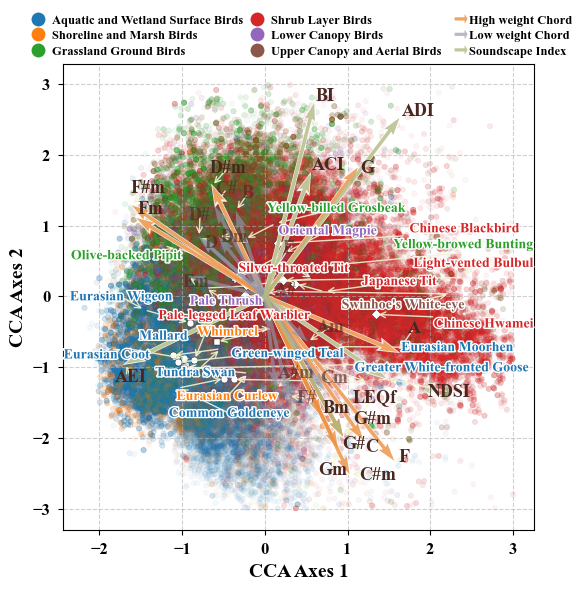

In [29]:

cmap=Tableau_10.mpl_colors[0:6] 

# 绘制 CCA 散点图，并标注鸟类的中心点
fig, ax = plt.subplots(figsize=(6, 6))
habitat_colors = dict(zip(habitat_order, cmap))  # 确保顺序一致

# 使用 seaborn 绘制散点图，并设置透明度、调色板、点大小等参数
scatter = sns.scatterplot(
    x='CCA1', y='CCA2', hue='habitat', data=df_cca, 
    palette=cmap, s=15, alpha=0.05, edgecolor=None,ax=ax
)

# 计算鸟类的中心点
bird_centroids = df_cca.groupby('bird')[['CCA1', 'CCA2']].mean()
# Step 5: 标注鸟类的中心点
markers = ['o', 's', '^', 'D', 'P', '*', 'X', 'v']  # 可以选择不同的形状
marker_map = dict(zip(habitat_order, markers[:len(habitat_order)]))  # 给每个 habitat 分配一个形状
texts = []
for i, bird in enumerate(bird_centroids.index):
    habitat = df_cca.loc[df_cca['bird'] == bird, 'habitat'].values[0]  # 找到该鸟类对应的 habitat
    color = habitat_colors[habitat]  # 获取对应 habitat 的颜色
    
    # 添加文本并设置描边效果
    text = ax.text(bird_centroids.iloc[i, 0], bird_centroids.iloc[i, 1], bird, 
                   fontsize=10, weight='bold', color=color, zorder=10,
                   path_effects=[path_effects.Stroke(linewidth=2, foreground='white'),
                                 path_effects.Normal()])  # 白色描边
    
    marker = marker_map[habitat]  # 根据 habitat 获取对应的形状
    # Step 2.1: 绘制点，点的大小为 100，形状根据 habitat 分配
    ax.scatter(bird_centroids.iloc[i, 0], bird_centroids.iloc[i, 1], 
               s=25, color='white', marker=marker, edgecolor='black', zorder=1)
    
    texts.append(text)
    
adjust_text(
    texts, 
    arrowprops=dict(
        arrowstyle='->,head_width=0.2,head_length=0.4',  
        color='#F3F4D5',  
        lw=1,  
        alpha=0.9 
    ),
    force_points=0.5,  # 力度调节，避免重叠
    expand_points=(1, 1),  # 让文本与点之间有额外的空间
    ax=ax, zorder=6  # 使用 ax 对象进行调整
) 

# 计算和弦的中心点向量
chord_vectors = cca.x_weights_[:chord_df.shape[1], :]  # CCA对和弦的向量表示
chord_vectors = pd.DataFrame(chord_vectors, columns=['CCA1', 'CCA2'])
chord_vectors = scalercca.transform(chord_vectors)
# 创建一个列表来存储未被过滤掉的和弦
remaining_chords = []
# 设置标准化的和弦长度
standard_length = 2.8
min_length_threshold = mean_length

# 计算所有向量的最大长度
chord_lengths = []
# 计算每个和弦的长度
for i, event in enumerate(chord_df.columns):
    # 计算和弦向量的长度
    vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
    chord_lengths.append(vector_length)
# 找到所有向量的最大长度
max_length = np.max(chord_lengths)


for i, event in enumerate(chord_df.columns):
    # 计算和弦向量的长度
    vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
    
    # 如果向量长度接近 0，跳过这个和弦
    if vector_length < min_length_threshold:
        continue

    # 将未被过滤掉的和弦添加到列表中
    remaining_chords.append(event)
    
    # # 标准化向量，将长度设为 standard_length
    # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
    
    # 归一化向量，将长度从 0 到 standard_length
    normalized_vector = chord_vectors[i] * (vector_length / max_length) * (standard_length / vector_length)
    
     # 绘制白色描边的箭头
    ax.quiver(0, 0, normalized_vector[0]* 1.02, normalized_vector[1]* 1.02,
              angles='xy', scale_units='xy', scale=1, color='white', alpha=0.9, width=0.01, zorder=3)
    # 绘制标准化后的向量箭头
    ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
              angles='xy', scale_units='xy', scale=1, color='#EC8F3F', alpha=0.8,zorder=4)
    
    # 可选：在箭头末端添加和弦名称
    text = ax.text(normalized_vector[0], normalized_vector[1], event, 
                   fontsize=13, color='#492620', weight='bold', zorder=100)
    texts.append(text)


# # 设置标准化的和弦长度
# standard_length = 2
# min_length_threshold = mean_length
for i, event in enumerate(chord_df.columns):
    # 计算和弦向量的长度
    vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
    
    # 如果向量长度接近 0，跳过这个和弦
    if vector_length > min_length_threshold:
        continue

    # 将未被过滤掉的和弦添加到列表中
    remaining_chords.append(event)
    
    # # 标准化向量，将长度设为 standard_length
    # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
    # 归一化向量，将长度从 0 到 standard_length
    normalized_vector = chord_vectors[i] * (vector_length / max_length) * (standard_length / vector_length)
    
    # 绘制标准化后的向量箭头
    ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
              angles='xy', scale_units='xy', scale=1, color='#9297AB', alpha=0.65,zorder=4)
    
    # 可选：在箭头末端添加和弦名称
    text = ax.text(normalized_vector[0], normalized_vector[1], event, 
                   fontsize=13, color='#492620', weight='bold', zorder=100,alpha=0.6)
    texts.append(text)

#声景指标
aindex=['LEQf','ACI','ADI','AEI','NDSI', 'BI']
for i, event in enumerate(aindex):
    # 计算和弦向量的长度
    vector_length = np.sqrt(vectors.loc[event, 'CCA1']**2 + vectors.loc[event, 'CCA2']**2)
    vector_lengtho = np.sqrt(vectors.loc[event, 'CCA1']**2 + vectors.loc[event, 'CCA2']**2)
    
    if event=='BI':
        vector_length = max_length
    
    # 将未被过滤掉的和弦添加到列表中
    remaining_chords.append(event)
    
    # # 标准化向量，将长度设为 standard_length
    # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
    
    # 归一化向量，将长度从 0 到 standard_length
    normalized_vector = vectors.loc[event,:] * (vector_length / max_length) * (standard_length / vector_lengtho)
    normalized_vector = np.array(normalized_vector)
    
     # 绘制白色描边的箭头
    ax.quiver(0, 0, normalized_vector[0]* 1.02, normalized_vector[1]* 1.02,
              angles='xy', scale_units='xy', scale=1, color='white', alpha=0.9, width=0.01, zorder=3)
    # 绘制标准化后的向量箭头
    ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
              angles='xy', scale_units='xy', scale=1, color='#B2BA81', alpha=0.8,zorder=4)
    
    # 可选：在箭头末端添加和弦名称
    text = ax.text(normalized_vector[0], normalized_vector[1], event, 
                   fontsize=13, color='#492620', weight='bold', zorder=100)
    texts.append(text)



adjust_text(
    texts, 
    arrowprops=dict(
        arrowstyle='->,head_width=0.2,head_length=0.4',  # 设置箭头样式（更宽的箭头头部）
        color='#F3F4D5',  
        lw=1,  
        alpha=0.9 
    ),
    force_points=0.3,  
    expand_points=(1.6, 1.6),  # 让文本与点之间有额外的空间
    ax=ax, zorder=8  # 使用 ax 对象进行调整
)


# 设置标题和网格，使用 ax 对象
ax.grid(True, linestyle='--', alpha=0.6)

# # 添加图例
# legend=ax.legend(title='', title_fontsize='13', fontsize='9', frameon=False,ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.1),  handletextpad=0.1,  columnspacing=0.1, labelspacing=0.3)

import matplotlib.lines as mlines
from matplotlib.patches import Arrow
from matplotlib.legend_handler import HandlerPatch
class HandlerArrow(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # 这里调整箭头的大小和位置，使其适应图例框
        px = 0.5 * width
        py = 0.5 * height
        arrow = Arrow(px, py, width / 2, 0, width=10, color=orig_handle.get_facecolor(), transform=trans)
        return [arrow]


habitats = habitat_order
colors = [habitat_colors[hab] for hab in habitats]
legend_labels = list(habitats)
legend_labels.extend( ['High weight Chord', 'Low weight Chord', 'Soundscape Index'])
legend_handles = [mlines.Line2D([], [], color=color, marker='o', linestyle='', markersize=10) for color in colors]

# 创建箭头图例标记
arrow_high_weight = Arrow(0, 0.5, 0.5, 0, width=0.1, color='#EC8F3F', alpha=0.8)
arrow_low_weight = Arrow(0, 0.3, 0.5, 0, width=0.1, color='#9297AB', alpha=0.65)
arrow_soundscape = Arrow(0, 0.1, 0.5, 0, width=0.1, color='#B2BA81', alpha=0.8)
# 将箭头添加到 legend_handles 列表中
legend_handles.extend([
    arrow_high_weight,  # High-weight Chord
    arrow_low_weight,   # Low-weight Chord
    arrow_soundscape    # Soundscape Index
])

legend = ax.legend(legend_handles, legend_labels, title='', title_fontsize='13', fontsize='9', frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13), handletextpad=0.1, columnspacing=0.1, labelspacing=0.3,handler_map={Arrow: HandlerArrow()})
    
    

# 设置轴标签，并包括解释比例
ax.set_xlabel('CCA Axes 1', fontsize=14)
ax.set_ylabel('CCA Axes 2', fontsize=14)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')  # 确保颜色为黑色
    label.set_fontsize(12)  # 确保颜色为黑色


# # 调整图形边距
plt.tight_layout()
plt.savefig('鸟的与音高.jpg', bbox_inches='tight', pad_inches=0.1,dpi=500)
# 显示图像
plt.show()

In [30]:

# cmap=Tableau_10.mpl_colors[0:6]
#
# # 绘制 CCA 散点图，并标注鸟类的中心点
# fig, ax = plt.subplots(figsize=(6, 6))
# habitat_colors = dict(zip(habitat_order, cmap))  # 确保顺序一致
#
# # 使用 seaborn 绘制散点图，并设置透明度、调色板、点大小等参数
# scatter = sns.scatterplot(
#     x='CCA1', y='CCA2', hue='habitat', data=df_cca,
#     palette=cmap, s=15, alpha=0.05, edgecolor=None,ax=ax
# )
#
# sns.rugplot(data=df_cca, x='CCA1', y='CCA2', height=.04, clip_on=True, lw=1, alpha=.003,color='#7F5A83')
#
# # 计算鸟类的中心点
# bird_centroids = df_cca.groupby('bird')[['CCA1', 'CCA2']].mean()
# # Step 5: 标注鸟类的中心点
# markers = ['o', 's', '^', 'D', 'P', '*', 'X', 'v']  # 可以选择不同的形状
# marker_map = dict(zip(habitat_order, markers[:len(habitat_order)]))  # 给每个 habitat 分配一个形状
# texts = []
# for i, bird in enumerate(bird_centroids.index):
#     habitat = df_cca.loc[df_cca['bird'] == bird, 'habitat'].values[0]  # 找到该鸟类对应的 habitat
#     color = habitat_colors[habitat]  # 获取对应 habitat 的颜色
#
#     # 添加文本并设置描边效果
#     text = ax.text(bird_centroids.iloc[i, 0], bird_centroids.iloc[i, 1], bird,
#                    fontsize=10, weight='bold', color=color, zorder=10,
#                    path_effects=[path_effects.Stroke(linewidth=2, foreground='white'),
#                                  path_effects.Normal()])  # 白色描边
#
#     marker = marker_map[habitat]  # 根据 habitat 获取对应的形状
#     # Step 2.1: 绘制点，点的大小为 100，形状根据 habitat 分配
#     ax.scatter(bird_centroids.iloc[i, 0], bird_centroids.iloc[i, 1],
#                s=25, color='white', marker=marker, edgecolor='black', zorder=1)
#
#     texts.append(text)
#
# adjust_text(
#     texts,
#     arrowprops=dict(
#         arrowstyle='->,head_width=0.2,head_length=0.4',
#         color='#F3F4D5',
#         lw=1,
#         alpha=0.9
#     ),
#     force_points=0.5,  # 力度调节，避免重叠
#     expand_points=(1, 1),  # 让文本与点之间有额外的空间
#     ax=ax, zorder=6  # 使用 ax 对象进行调整
# )
#
# # 计算和弦的中心点向量
# chord_vectors = cca.x_weights_[:chord_df.shape[1], :]  # CCA对和弦的向量表示
# chord_vectors = pd.DataFrame(chord_vectors, columns=['CCA1', 'CCA2'])
# chord_vectors = scalercca.transform(chord_vectors)
# # 创建一个列表来存储未被过滤掉的和弦
# remaining_chords = []
# # 设置标准化的和弦长度
# standard_length = 2.8
# min_length_threshold = mean_length
#
# # 计算所有向量的最大长度
# chord_lengths = []
# # 计算每个和弦的长度
# for i, event in enumerate(chord_df.columns):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
#     chord_lengths.append(vector_length)
# # 找到所有向量的最大长度
# max_length = np.max(chord_lengths)
#
#
# for i, event in enumerate(chord_df.columns):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
#
#     # 如果向量长度接近 0，跳过这个和弦
#     if vector_length < min_length_threshold:
#         continue
#
#     # 将未被过滤掉的和弦添加到列表中
#     remaining_chords.append(event)
#
#     # # 标准化向量，将长度设为 standard_length
#     # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
#
#     # 归一化向量，将长度从 0 到 standard_length
#     normalized_vector = chord_vectors[i] * (vector_length / max_length) * (standard_length / vector_length)
#
#      # 绘制白色描边的箭头
#     ax.quiver(0, 0, normalized_vector[0]* 1.02, normalized_vector[1]* 1.02,
#               angles='xy', scale_units='xy', scale=1, color='white', alpha=0.9, width=0.01, zorder=3)
#     # 绘制标准化后的向量箭头
#     ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
#               angles='xy', scale_units='xy', scale=1, color='#EC8F3F', alpha=0.8,zorder=4)
#
#     # 可选：在箭头末端添加和弦名称
#     text = ax.text(normalized_vector[0], normalized_vector[1], event,
#                    fontsize=13, color='#492620', weight='bold', zorder=100)
#     texts.append(text)
#
#
# # # 设置标准化的和弦长度
# # standard_length = 2
# # min_length_threshold = mean_length
# for i, event in enumerate(chord_df.columns):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(chord_vectors[i, 0]**2 + chord_vectors[i, 1]**2)
#
#     # 如果向量长度接近 0，跳过这个和弦
#     if vector_length > min_length_threshold:
#         continue
#
#     # 将未被过滤掉的和弦添加到列表中
#     remaining_chords.append(event)
#
#     # # 标准化向量，将长度设为 standard_length
#     # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
#     # 归一化向量，将长度从 0 到 standard_length
#     normalized_vector = chord_vectors[i] * (vector_length / max_length) * (standard_length / vector_length)
#
#     # 绘制标准化后的向量箭头
#     ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
#               angles='xy', scale_units='xy', scale=1, color='#9297AB', alpha=0.65,zorder=4)
#
#     # 可选：在箭头末端添加和弦名称
#     text = ax.text(normalized_vector[0], normalized_vector[1], event,
#                    fontsize=13, color='#492620', weight='bold', zorder=100,alpha=0.6)
#     texts.append(text)
#
# #声景指标
# aindex=['LEQf','ACI','ADI','AEI','NDSI', 'BI']
# for i, event in enumerate(aindex):
#     # 计算和弦向量的长度
#     vector_length = np.sqrt(vectors.loc[event, 'CCA1']**2 + vectors.loc[event, 'CCA2']**2)
#     vector_lengtho = np.sqrt(vectors.loc[event, 'CCA1']**2 + vectors.loc[event, 'CCA2']**2)
#
#     if event=='BI':
#         vector_length = max_length
#
#     # 将未被过滤掉的和弦添加到列表中
#     remaining_chords.append(event)
#
#     # # 标准化向量，将长度设为 standard_length
#     # normalized_vector = chord_vectors[i] * (standard_length / vector_length)
#
#     # 归一化向量，将长度从 0 到 standard_length
#     normalized_vector = vectors.loc[event,:] * (vector_length / max_length) * (standard_length / vector_lengtho)
#     normalized_vector = np.array(normalized_vector)
#
#      # 绘制白色描边的箭头
#     ax.quiver(0, 0, normalized_vector[0]* 1.02, normalized_vector[1]* 1.02,
#               angles='xy', scale_units='xy', scale=1, color='white', alpha=0.9, width=0.01, zorder=3)
#     # 绘制标准化后的向量箭头
#     ax.quiver(0, 0, normalized_vector[0], normalized_vector[1],
#               angles='xy', scale_units='xy', scale=1, color='#B2BA81', alpha=0.8,zorder=4)
#
#     # 可选：在箭头末端添加和弦名称
#     text = ax.text(normalized_vector[0], normalized_vector[1], event,
#                    fontsize=13, color='#492620', weight='bold', zorder=100)
#     texts.append(text)
#
#
#
# adjust_text(
#     texts,
#     arrowprops=dict(
#         arrowstyle='->,head_width=0.2,head_length=0.4',  # 设置箭头样式（更宽的箭头头部）
#         color='#F3F4D5',
#         lw=1,
#         alpha=0.9
#     ),
#     force_points=0.3,
#     expand_points=(1.6, 1.6),  # 让文本与点之间有额外的空间
#     ax=ax, zorder=8  # 使用 ax 对象进行调整
# )
#
#
# # 设置标题和网格，使用 ax 对象
# ax.grid(True, linestyle='--', alpha=0.6)
#
# # # 添加图例
# # legend=ax.legend(title='', title_fontsize='13', fontsize='9', frameon=False,ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.1),  handletextpad=0.1,  columnspacing=0.1, labelspacing=0.3)
#
# import matplotlib.lines as mlines
# from matplotlib.patches import Arrow
# from matplotlib.legend_handler import HandlerPatch
# class HandlerArrow(HandlerPatch):
#     def create_artists(self, legend, orig_handle,
#                        xdescent, ydescent, width, height, fontsize, trans):
#         # 这里调整箭头的大小和位置，使其适应图例框
#         px = 0.5 * width
#         py = 0.5 * height
#         arrow = Arrow(px, py, width / 2, 0, width=10, color=orig_handle.get_facecolor(), transform=trans)
#         return [arrow]
#
#
# habitats = habitat_order
# colors = [habitat_colors[hab] for hab in habitats]
# legend_labels = list(habitats)
# legend_labels.extend( ['High weight Chord', 'Low weight Chord', 'Soundscape Index'])
# legend_handles = [mlines.Line2D([], [], color=color, marker='o', linestyle='', markersize=10) for color in colors]
#
# # 创建箭头图例标记
# arrow_high_weight = Arrow(0, 0.5, 0.5, 0, width=0.1, color='#EC8F3F', alpha=0.8)
# arrow_low_weight = Arrow(0, 0.3, 0.5, 0, width=0.1, color='#9297AB', alpha=0.65)
# arrow_soundscape = Arrow(0, 0.1, 0.5, 0, width=0.1, color='#B2BA81', alpha=0.8)
# # 将箭头添加到 legend_handles 列表中
# legend_handles.extend([
#     arrow_high_weight,  # High-weight Chord
#     arrow_low_weight,   # Low-weight Chord
#     arrow_soundscape    # Soundscape Index
# ])
#
# legend = ax.legend(legend_handles, legend_labels, title='', title_fontsize='13', fontsize='9', frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13), handletextpad=0.1, columnspacing=0.1, labelspacing=0.3,handler_map={Arrow: HandlerArrow()})
#
#
#
# # 设置轴标签，并包括解释比例
# ax.set_xlabel('CCA Axes 1', fontsize=14)
# ax.set_ylabel('CCA Axes 2', fontsize=14)
# ax.tick_params(axis='y', labelsize=10)
# ax.tick_params(axis='x', labelsize=10)
#
# # # 调整图形边距
# plt.tight_layout()
# plt.savefig('鸟的与音高2.jpg', bbox_inches='tight', pad_inches=0.1,dpi=500)
# # 显示图像
# plt.show()

In [31]:
event

'BI'

In [32]:
vector_length

np.float64(0.07283044714880729)

In [33]:
max_length

np.float64(0.07283044714880729)

In [34]:
(vector_length / max_length) * standard_length

np.float64(2.8)